# eval DB viewer

Read-only look at the two shared SQLite DBs.

- **records (ops DB)** `easyads_ops.db` — jobs / node_executions / llm_calls / schema_validations / job_cost_summary / dirty_field_events
- **eval DB** `easyads_eval.db` — eval_runs / score_items / gate_results / domain_scores / judge_status

Run the **Setup** cell first, then any cell below. Re-run a cell to refresh (safe to run while `make eval-sample` is generating).

**Validity rule:** a job is real only if every `llm_calls.fallback_used = 0` AND `t2i_engine = gpt_image_2` AND `imgs >= 1`. Any `fallback_used = 1` -> discard that job.

## Setup

In [42]:
import os, sqlite3

# polars(빠른 Rust DataFrame)로 표시. 미설치 환경(호스트 .venv 등)에선 stdlib _Table 폴백 →
# 노트북이 어디서든 hard-fail 안 함. 컨테이너(Dockerfile.eval)엔 polars 포함.
try:
    import polars as pl
    pl.Config.set_tbl_rows(60)
    pl.Config.set_tbl_cols(-1)
    pl.Config.set_fmt_str_lengths(80)
    _HAVE_POLARS = True
except ModuleNotFoundError:
    _HAVE_POLARS = False


class _Table:
    """polars 미설치용 경량 폴백 — q()와 동일 인터페이스([r, c] 인덱싱, len) 유지해
    아래 셀들의 df[0, 0] / len(df) 가 polars 유무와 무관하게 동작."""
    def __init__(self, columns, rows):
        self.columns, self.rows = columns, rows
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, key):
        if isinstance(key, tuple):
            r, c = key
            return self.rows[r][c]
        return self.rows[key]
    def __repr__(self):
        if not self.rows:
            return " | ".join(self.columns) + "\n(0 rows)"
        w = [max([len(str(c))] + [len(str(r[i])) for r in self.rows]) for i, c in enumerate(self.columns)]
        head = " | ".join(str(c).ljust(w[i]) for i, c in enumerate(self.columns))
        sep = "-+-".join("-" * x for x in w)
        body = "\n".join(" | ".join(str(v).ljust(w[i]) for i, v in enumerate(r)) for r in self.rows)
        return f"{head}\n{sep}\n{body}"


# /home/records on host, /app/records inside a container. Override with RECORDS_DIR.
RECORDS = os.environ.get('RECORDS_DIR') or next(
    (p for p in ('/home/records', '/app/records') if os.path.isdir(p)), '/home/records')
OPS_DB  = os.path.join(RECORDS, 'easyads_ops.db')
EVAL_DB = os.path.join(RECORDS, 'easyads_eval.db')


def q(db, sql, params=()):
    """읽기전용 쿼리 실행 → polars DataFrame(있으면) 또는 _Table 폴백."""
    with sqlite3.connect(db) as c:
        cur = c.execute(sql, params)
        rows = [tuple(r) for r in cur.fetchall()]
        cols = [d[0] for d in cur.description]
    if _HAVE_POLARS:
        return pl.DataFrame(rows, schema=cols, orient="row") if rows else pl.DataFrame(schema=cols)
    return _Table(cols, rows)


print('polars  :', 'yes' if _HAVE_POLARS else 'NO (stdlib fallback)')
print('RECORDS :', RECORDS)
print('OPS_DB  :', OPS_DB,  '(exists)' if os.path.isfile(OPS_DB)  else '(MISSING)')
print('EVAL_DB :', EVAL_DB, '(exists)' if os.path.isfile(EVAL_DB) else '(MISSING)')

polars  : yes
RECORDS : /app/records
OPS_DB  : /app/records/easyads_ops.db (exists)
EVAL_DB : /app/records/easyads_eval.db (exists)


In [43]:
os.getcwd()

'/app/orchestrator/eval'

# records (ops DB)

### jobs — overview (newest first)

In [44]:
q(OPS_DB, '''
  SELECT job_id, user_plan AS plan, render_profile AS render, status,
         entry_mode, revision, created_at
  FROM jobs ORDER BY created_at DESC LIMIT 30
''')

job_id,plan,render,status,entry_mode,revision,created_at
str,str,str,str,str,i64,str
"""test_store_grand_open_20260608004905""","""premium""","""balanced""","""done""","""chat_start""",1,"""2026-06-08T00:49:06.040549+00:00"""
"""test_cafe_iced_americano_20260608000015""","""free""","""balanced""","""done""","""chat_start""",1,"""2026-06-08T00:00:15.815007+00:00"""
"""test_store_yearend_gift_20260607192552""","""free""","""balanced""","""done""","""chat_start""",1,"""2026-06-07T19:25:53.108605+00:00"""
"""test_fitness_free_trial_20260607173418""","""premium""","""balanced""","""done""","""chat_start""",1,"""2026-06-07T17:34:18.649829+00:00"""
"""test_bespoke_florist_20260606202514""","""free""","""balanced""","""done""","""chat_start""",1,"""2026-06-06T20:25:14.800877+00:00"""


### llm_calls — fallback summary per job (fb_total must be 0 for a valid run)

In [45]:
q(OPS_DB, '''
  SELECT job_id,
         COUNT(*)            AS llm_calls,
         SUM(fallback_used)  AS fb_total,
         SUM(success)        AS ok_total,
         GROUP_CONCAT(DISTINCT error_code) AS errors
  FROM llm_calls GROUP BY job_id ORDER BY job_id DESC LIMIT 30
''')

job_id,llm_calls,fb_total,ok_total,errors
str,i64,i64,i64,str
"""test_store_yearend_gift_20260607192552""",2,2,0,"""free_plan_deterministic_fallback"""
"""test_store_grand_open_20260608004905""",5,0,5,null
"""test_fitness_free_trial_20260607173418""",4,0,4,null
"""test_cafe_iced_americano_20260608000015""",2,2,0,"""free_plan_deterministic_fallback"""
"""test_bespoke_florist_20260606202514""",2,2,0,"""free_plan_deterministic_fallback"""


### llm_calls — per-node detail (model / fallback / error / cost)

In [46]:
q(OPS_DB, '''
  SELECT job_id, node_name, model_class, model_name,
         success AS ok, fallback_used AS fb,
         COALESCE(error_code,'') AS error_code,
         total_tokens AS tok, cost_usd, cost_source
  FROM llm_calls ORDER BY id DESC LIMIT 60
''')

job_id,node_name,model_class,model_name,ok,fb,error_code,tok,cost_usd,cost_source
str,str,str,str,i64,i64,str,i64,f64,str
"""test_store_grand_open_20260608004905""","""prompt_critic""","""api_full""","""api_full""",1,0,"""""",1987,0.019305,"""exact"""
"""test_store_grand_open_20260608004905""","""copy_candidate_generation""","""api_mini""","""api_mini""",1,0,"""""",3423,0.005222,"""exact"""
"""test_store_grand_open_20260608004905""","""tone_binding""","""api_mini""","""api_mini""",1,0,"""""",1269,0.0027855,"""exact"""
"""test_store_grand_open_20260608004905""","""validator""","""api_mini""","""api_mini""",1,0,"""""",600,0.0008475,"""exact"""
"""test_store_grand_open_20260608004905""","""validator""","""api_mini""","""api_mini""",1,0,"""""",595,0.000844,"""exact"""
"""test_cafe_iced_americano_20260608000015""","""copy_candidate_generation""","""local_quality""","""local_quality""",0,1,"""free_plan_deterministic_fallback""",null,0.0,"""self_hosted"""
"""test_cafe_iced_americano_20260608000015""","""tone_binding""","""mock""","""mock""",0,1,"""free_plan_deterministic_fallback""",null,0.0,"""adapter"""
"""test_store_yearend_gift_20260607192552""","""copy_candidate_generation""","""local_quality""","""local_quality""",0,1,"""free_plan_deterministic_fallback""",null,0.0,"""self_hosted"""
"""test_store_yearend_gift_20260607192552""","""tone_binding""","""mock""","""mock""",0,1,"""free_plan_deterministic_fallback""",null,0.0,"""adapter"""


### node_executions — status & latency (t2i_generation dominates wall time)

In [47]:
# set a job_id to focus, or leave '' for the latest job
JOB_ID = ''
if not JOB_ID:
    JOB_ID = q(OPS_DB, 'SELECT job_id FROM jobs ORDER BY created_at DESC LIMIT 1')[0, 0]
print('JOB_ID =', JOB_ID)
q(OPS_DB, '''
  SELECT node_name, status, latency_ms AS ms,
         SUBSTR(COALESCE(error_message,''),1,50) AS err
  FROM node_executions WHERE job_id=? ORDER BY id
''', (JOB_ID,))

JOB_ID = test_store_grand_open_20260608004905


node_name,status,ms,err
str,str,i64,str
"""input""","""completed""",8,""""""
"""validator""","""completed""",3897,""""""
"""options""","""started""",null,""""""
"""options""","""completed""",2,""""""
"""state_update""","""completed""",2,""""""
"""validator""","""completed""",2112,""""""
"""format_planner""","""completed""",2,""""""
"""tone_binding""","""completed""",4086,""""""
"""copy_candidate_generation""","""completed""",4609,""""""


### job_cost_summary — tokens, USD, T2I engine & image cost

In [48]:
q(OPS_DB, '''
  SELECT job_id, total_api_calls AS api, fallback_calls AS fb,
         total_tokens AS tok, total_cost_usd AS usd,
         t2i_engine, t2i_image_count AS imgs, t2i_cost_usd, t2i_cost_source,
         cost_estimated AS est
  FROM job_cost_summary ORDER BY rowid DESC LIMIT 30
''')

job_id,api,fb,tok,usd,t2i_engine,imgs,t2i_cost_usd,t2i_cost_source,est
str,i64,i64,i64,f64,str,i64,f64,str,i64
"""test_store_grand_open_20260608004905""",5,0,7874,0.050967,"""sd35_large""",1,0.021963,"""gpu_exact""",0
"""test_cafe_iced_americano_20260608000015""",0,2,0,0.019133,"""sd35_large""",1,0.019133,"""gpu_exact""",0
"""test_store_yearend_gift_20260607192552""",0,2,0,0.0,"""sd35_large""",1,null,"""gpu_unpriced""",1
"""test_fitness_free_trial_20260607173418""",4,0,7412,0.029578,"""sd35_large""",1,null,"""gpu_unpriced""",1
"""test_bespoke_florist_20260606202514""",0,2,0,0.0,"""sd35_large""",1,null,"""gpu_unpriced""",1


### images — generated file paths (result node)

In [49]:
q(OPS_DB, '''
  SELECT ne.job_id,
         json_extract(nso.output_snapshot,'$.result_payload.output_path')           AS final_ad,
         json_extract(nso.output_snapshot,'$.result_payload.background_image_path')  AS background
  FROM node_state_outputs nso
  JOIN node_executions ne ON ne.id = nso.node_exec_id
  WHERE ne.node_name='result'
  GROUP BY ne.job_id ORDER BY ne.id DESC LIMIT 30
''')

job_id,final_ad,background
str,str,str
"""test_store_grand_open_20260608004905""","""/app/records/images/test_store_grand_open_20260608004905/final_composite.png""","""/app/records/images/test_store_grand_open_20260608004905/sd35_large_0.png"""
"""test_cafe_iced_americano_20260608000015""","""/app/records/images/test_cafe_iced_americano_20260608000015/final_composite.png""","""/app/records/images/test_cafe_iced_americano_20260608000015/sd35_large_0.png"""
"""test_store_yearend_gift_20260607192552""","""/app/records/images/test_store_yearend_gift_20260607192552/final_composite.png""","""/app/records/images/test_store_yearend_gift_20260607192552/sd35_large_0.png"""
"""test_fitness_free_trial_20260607173418""","""/app/records/images/test_fitness_free_trial_20260607173418/final_composite.png""","""/app/records/images/test_fitness_free_trial_20260607173418/sd35_large_0.png"""
"""test_bespoke_florist_20260606202514""","""/app/records/images/test_bespoke_florist_20260606202514/final_composite.png""","""/app/records/images/test_bespoke_florist_20260606202514/sd35_large_0.png"""


### schema_validations — failures only (empty = all passed)

In [50]:
q(OPS_DB, '''
  SELECT job_id, node_name, schema_name, field_name,
         SUBSTR(COALESCE(error_detail,''),1,80) AS err
  FROM schema_validations WHERE passed=0 ORDER BY id DESC LIMIT 50
''')

job_id,node_name,schema_name,field_name,err
null,null,null,null,null


### preview a generated image (optional)

path: /app/records/images/test_store_grand_open_20260608004905/final_composite.png


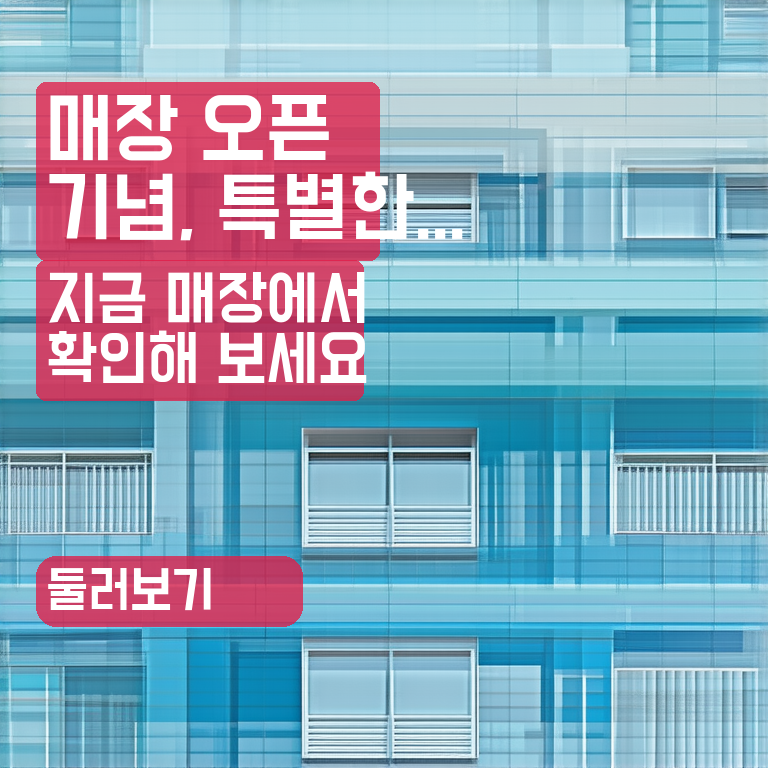

In [51]:
from IPython.display import Image, display
row = q(OPS_DB, '''
  SELECT json_extract(nso.output_snapshot,'$.result_payload.output_path') AS final_ad
  FROM node_state_outputs nso JOIN node_executions ne ON ne.id=nso.node_exec_id
  WHERE ne.node_name='result' ORDER BY ne.id DESC LIMIT 1
''')
path = row[0, 0] if len(row) else None
print('path:', path)
if path and os.path.isfile(path):
    display(Image(filename=path))
else:
    print('file not reachable from here (may be a container path); open it directly.')

# eval DB

### eval_runs — overall score & verdict

In [52]:
q(EVAL_DB, '''
  SELECT job_id, eval_id, ROUND(overall_score,3) AS score, verdict,
         evaluator_id, evaluated_at
  FROM eval_runs ORDER BY evaluated_at DESC LIMIT 30
''')

job_id,eval_id,score,verdict,evaluator_id,evaluated_at
str,str,f64,str,null,str
"""test_store_grand_open_20260608004905""","""eval_83eddd44accc4d79ba8cfa989fcff102""",null,"""pending_scores""",null,"""2026-06-08T00:51:32.527499+00:00"""
"""test_cafe_iced_americano_20260608000015""","""eval_2b15898d48e74bddbc94c873829d4a3e""",3.412,"""major_revision""",null,"""2026-06-08T00:01:53.764151+00:00"""
"""test_store_yearend_gift_20260607192552""","""eval_d0babc4546b24504a03587bbfb212329""",3.686,"""major_revision""",null,"""2026-06-07T19:27:36.217588+00:00"""
"""test_fitness_free_trial_20260607173418""","""eval_7aa7e6531acb41c0b64d5dcd59e99fb0""",3.502,"""major_revision""",null,"""2026-06-07T17:36:34.492860+00:00"""
"""test_bespoke_florist_20260606202514""","""eval_d7ed198bb9334aa7aeceed61c42b7ffc""",3.248,"""major_revision""",null,"""2026-06-06T20:26:52.107689+00:00"""


### score_items — per-item scores by evaluator (llm / vlm / human)

In [53]:
q(EVAL_DB, '''
  SELECT er.job_id, si.evaluator_type, si.item_id, si.score,
         SUBSTR(COALESCE(si.notes,''),1,60) AS notes
  FROM score_items si JOIN eval_runs er ON er.eval_id = si.eval_id
  ORDER BY er.evaluated_at DESC, si.evaluator_type, si.item_id LIMIT 80
''')

job_id,evaluator_type,item_id,score,notes
str,str,str,i64,str
"""test_cafe_iced_americano_20260608000015""","""llm""","""II-1""",3,"""The context captures business type (cafe), item/service (대표 """
"""test_cafe_iced_americano_20260608000015""","""llm""","""II-2""",5,"""The validator reports no missing_fields and retains all rele"""
"""test_cafe_iced_americano_20260608000015""","""llm""","""II-3""",5,"""The updated context is internally consistent between state_u"""
"""test_cafe_iced_americano_20260608000015""","""llm""","""III-3""",3,"""감성적인 카페 분위기의 헤드라인/서브카피와 CTA는 톤에 부합하지만, 요청된 '여름 시즌 아이스 아메리카노 """
"""test_cafe_iced_americano_20260608000015""","""llm""","""III-4""",4,"""CTA인 ""메뉴 확인하기"" is clear and actionable but lacks stronger sp"""
"""test_cafe_iced_americano_20260608000015""","""llm""","""III-5""",4,"""Copy is largely consistent with the stated emotional cafe br"""
"""test_cafe_iced_americano_20260608000015""","""llm""","""IV-3""",4,"""The spec defines appropriate distinct slots for headline, su"""
"""test_cafe_iced_americano_20260608000015""","""llm""","""IV-4""",3,"""The spec defines headline vs body weights and size ratios (h"""
"""test_cafe_iced_americano_20260608000015""","""llm""","""IV-5""",3,"""Evidence shows a text layout plan with a dynamic side-split """


### gate_results — auto gates pass/fail

In [54]:
q(EVAL_DB, '''
  SELECT er.job_id, gr.gate_id, gr.passed,
         SUBSTR(COALESCE(gr.failure_reason,''),1,70) AS failure_reason,
         gr.auto_evaluated
  FROM gate_results gr JOIN eval_runs er ON er.eval_id = gr.eval_id
  ORDER BY er.evaluated_at DESC, gr.gate_id LIMIT 60
''')

job_id,gate_id,passed,failure_reason,auto_evaluated
str,str,i64,str,i64
"""test_store_grand_open_20260608004905""","""III-2""",1,"""""",1
"""test_store_grand_open_20260608004905""","""V-1""",1,"""""",1
"""test_store_grand_open_20260608004905""","""V-2""",1,"""""",1
"""test_store_grand_open_20260608004905""","""VI-1""",1,"""""",1
"""test_store_grand_open_20260608004905""","""VI-3""",1,"""""",1
"""test_cafe_iced_americano_20260608000015""","""III-2""",1,"""""",1
"""test_cafe_iced_americano_20260608000015""","""V-1""",1,"""""",1
"""test_cafe_iced_americano_20260608000015""","""V-2""",1,"""""",1
"""test_cafe_iced_americano_20260608000015""","""VI-1""",1,"""""",1


### domain_scores — aggregated per domain

In [55]:
q(EVAL_DB, '''
  SELECT er.job_id, ds.domain, ROUND(ds.avg_score,3) AS avg_score,
         ds.weight, ROUND(ds.weighted_contribution,3) AS weighted, ds.item_count
  FROM domain_scores ds JOIN eval_runs er ON er.eval_id = ds.eval_id
  ORDER BY er.evaluated_at DESC, ds.domain LIMIT 60
''')

job_id,domain,avg_score,weight,weighted,item_count
str,str,null,f64,null,i64
"""test_store_grand_open_20260608004905""","""II""",null,0.3,null,0
"""test_store_grand_open_20260608004905""","""III""",null,0.2,null,0
"""test_store_grand_open_20260608004905""","""IV""",null,0.3,null,0
"""test_store_grand_open_20260608004905""","""V""",null,0.1,null,0
"""test_cafe_iced_americano_20260608000015""","""II""",null,0.3,null,0
"""test_cafe_iced_americano_20260608000015""","""III""",null,0.2,null,0
"""test_cafe_iced_americano_20260608000015""","""IV""",null,0.3,null,0
"""test_cafe_iced_americano_20260608000015""","""V""",null,0.1,null,0
"""test_store_yearend_gift_20260607192552""","""II""",null,0.3,null,0


### judge_status — idempotent judge queue (attempts / errors)

In [56]:
q(EVAL_DB, '''
  SELECT eval_id, evaluator_type, status, attempts,
         SUBSTR(COALESCE(last_error,''),1,70) AS last_error
  FROM judge_status ORDER BY rowid DESC LIMIT 40
''')

eval_id,evaluator_type,status,attempts,last_error
str,str,str,i64,str
"""eval_d7ed198bb9334aa7aeceed61c42b7ffc""","""vlm""","""done""",1,""""""
"""eval_d7ed198bb9334aa7aeceed61c42b7ffc""","""llm""","""done""",1,""""""
"""eval_7aa7e6531acb41c0b64d5dcd59e99fb0""","""vlm""","""done""",1,""""""
"""eval_7aa7e6531acb41c0b64d5dcd59e99fb0""","""llm""","""done""",1,""""""
"""eval_d0babc4546b24504a03587bbfb212329""","""vlm""","""done""",1,""""""
"""eval_d0babc4546b24504a03587bbfb212329""","""llm""","""done""",1,""""""
"""eval_2b15898d48e74bddbc94c873829d4a3e""","""vlm""","""done""",1,""""""
"""eval_2b15898d48e74bddbc94c873829d4a3e""","""llm""","""done""",1,""""""


# 일자별 요약 (per-day)

ops/eval DB를 `date()`로 묶어 하루 단위 활동·비용·점수를 본다.

### 하루별 생성/비용 (ops) — job 수, plan 구성, T2I 엔진, 토큰, LLM+T2I 비용

In [57]:
q(OPS_DB, '''
  SELECT date(j.created_at) AS day, COUNT(*) AS jobs,
         SUM(j.user_plan='premium') AS premium, SUM(j.user_plan='free') AS free,
         GROUP_CONCAT(DISTINCT c.t2i_engine) AS engines,
         SUM(c.total_tokens) AS tokens,
         ROUND(SUM(COALESCE(c.total_cost_usd,0)),5) AS gen_usd,
         ROUND(SUM(COALESCE(c.t2i_cost_usd,0)),5) AS t2i_usd
  FROM jobs j LEFT JOIN job_cost_summary c USING(job_id)
  GROUP BY day ORDER BY day DESC
''')

day,jobs,premium,free,engines,tokens,gen_usd,t2i_usd
str,i64,i64,i64,str,i64,f64,f64
"""2026-06-08""",2,1,1,"""sd35_large""",7874,0.0701,0.0411
"""2026-06-07""",2,1,1,"""sd35_large""",7412,0.02958,0.0
"""2026-06-06""",1,0,1,"""sd35_large""",0,0.0,0.0


### 하루별 평가 점수 (eval) — eval 수, 평균/최저 점수, verdict 분포

In [58]:
q(EVAL_DB, '''
  SELECT date(evaluated_at) AS day, COUNT(*) AS evals,
         ROUND(AVG(overall_score),2) AS avg_score,
         ROUND(MIN(overall_score),2) AS min_score,
         GROUP_CONCAT(DISTINCT verdict) AS verdicts
  FROM eval_runs GROUP BY day ORDER BY day DESC
''')

day,evals,avg_score,min_score,verdicts
str,i64,f64,f64,str
"""2026-06-08""",2,3.41,3.41,"""major_revision,pending_scores"""
"""2026-06-07""",2,3.59,3.5,"""major_revision"""
"""2026-06-06""",1,3.25,3.25,"""major_revision"""


### 특정 일자 드릴다운 — `DAY` 지정(빈 값이면 최신 활동일). 그 날의 job · LLM호출 · 점수.

In [59]:
from IPython.display import display
# DAY='' 면 가장 최근 job이 있는 날짜로 자동
DAY = ''
if not DAY:
    DAY = q(OPS_DB, "SELECT date(MAX(created_at)) FROM jobs")[0, 0]
print('DAY =', DAY)

print('\n— jobs —')
display(q(OPS_DB, '''
  SELECT j.job_id, j.user_plan AS plan, j.status, c.t2i_engine AS engine,
         c.total_tokens AS tok,
         COALESCE(printf('%.6f', c.t2i_cost_usd), c.t2i_cost_source) AS t2i_cost
  FROM jobs j LEFT JOIN job_cost_summary c USING(job_id)
  WHERE date(j.created_at)=? ORDER BY j.created_at''', (DAY,)))

print('\n— llm_calls —')
display(q(OPS_DB, '''
  SELECT job_id, node_name, model_class AS cls, success AS ok,
         fallback_used AS fb, COALESCE(error_code,'') AS err
  FROM llm_calls WHERE date(created_at)=? ORDER BY id''', (DAY,)))

print('\n— eval scores —')
display(q(EVAL_DB, '''
  SELECT job_id, ROUND(overall_score,2) AS score, verdict
  FROM eval_runs WHERE date(evaluated_at)=? ORDER BY evaluated_at''', (DAY,)))

DAY = 2026-06-08

— jobs —


job_id,plan,status,engine,tok,t2i_cost
str,str,str,str,i64,str
"""test_cafe_iced_americano_20260608000015""","""free""","""done""","""sd35_large""",0,"""0.019133"""
"""test_store_grand_open_20260608004905""","""premium""","""done""","""sd35_large""",7874,"""0.021963"""



— llm_calls —


job_id,node_name,cls,ok,fb,err
str,str,str,i64,i64,str
"""test_cafe_iced_americano_20260608000015""","""tone_binding""","""mock""",0,1,"""free_plan_deterministic_fallback"""
"""test_cafe_iced_americano_20260608000015""","""copy_candidate_generation""","""local_quality""",0,1,"""free_plan_deterministic_fallback"""
"""test_store_grand_open_20260608004905""","""validator""","""api_mini""",1,0,""""""
"""test_store_grand_open_20260608004905""","""validator""","""api_mini""",1,0,""""""
"""test_store_grand_open_20260608004905""","""tone_binding""","""api_mini""",1,0,""""""
"""test_store_grand_open_20260608004905""","""copy_candidate_generation""","""api_mini""",1,0,""""""
"""test_store_grand_open_20260608004905""","""prompt_critic""","""api_full""",1,0,""""""



— eval scores —


job_id,score,verdict
str,f64,str
"""test_cafe_iced_americano_20260608000015""",3.41,"""major_revision"""
"""test_store_grand_open_20260608004905""",null,"""pending_scores"""


### 파일명/job_id로 이미지 보기
`show_image(name)` — 전체경로 · 파일명 · job_id 중 무엇이든. `kind='final'`(최종합성) | `'bg'`(배경).

/app/records/images/test_store_grand_open_20260608004905/final_composite.png


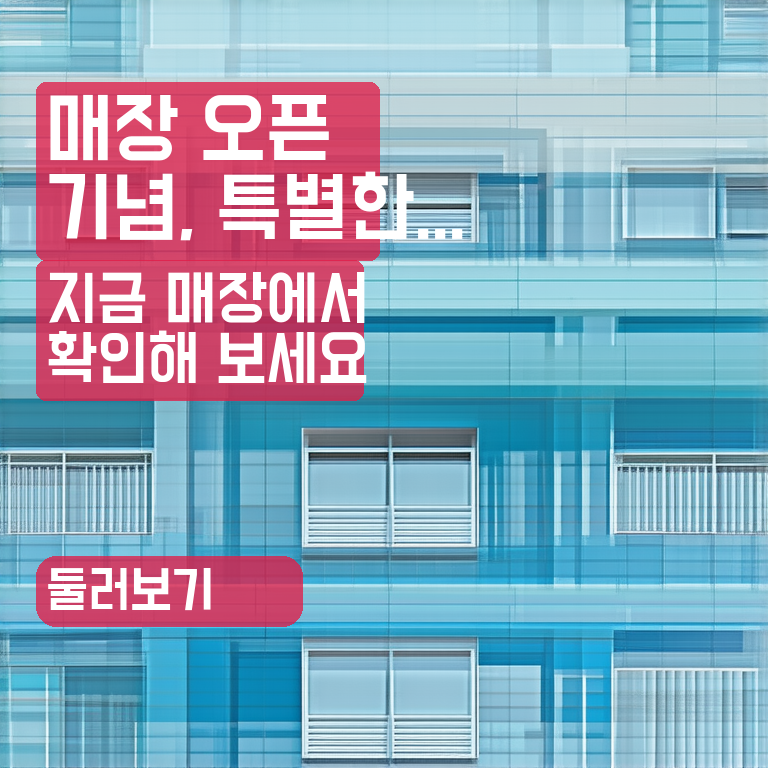

In [60]:
from IPython.display import Image, display
import glob, os

def show_image(name, kind='final'):
    """이미지 표시. name = 전체경로 | 파일명(final_composite.png 등) | job_id.
    kind: 'final'(최종 광고) | 'bg'(텍스트 없는 배경). job_id일 때만 적용."""
    name = (name or '').strip()
    img_root = os.path.join(RECORDS, 'images')
    cand = []
    if os.path.isfile(name):                                    # 1) 전체경로
        cand = [name]
    else:
        patt = 'final_composite*.png' if kind == 'final' else '*background*.png'
        job_dir = os.path.join(img_root, name)
        if os.path.isdir(job_dir):                              # 2) job_id 폴더
            cand = sorted(glob.glob(os.path.join(job_dir, patt))) or sorted(glob.glob(os.path.join(job_dir, '*.png')))
        if not cand:                                            # 3) 파일명(부분일치) 트리 검색
            cand = sorted(glob.glob(os.path.join(img_root, '**', name), recursive=True)) \
                or sorted(glob.glob(os.path.join(img_root, '**', '*' + name + '*'), recursive=True))
    if not cand:
        print('찾지 못함:', name, '| ', img_root, '아래에서 검색'); return
    for p in cand:
        print(p)
        display(Image(filename=p))

# 사용 예: show_image('test_cafe_iced_americano_20260608000015')  /  show_image('final_composite.png')  /  show_image(<job_id>, kind='bg')
show_image(q(OPS_DB, "SELECT job_id FROM jobs ORDER BY created_at DESC LIMIT 1")[0, 0])

In [41]:
show_image('test_store_custom_copy_20260605044855')

찾지 못함: test_store_custom_copy_20260605044855 |  /app/records/images 아래에서 검색
